# 05 - Customer Sentiment & NLP Analytics

# Digikala Content Analytics & AI Insight Platform


## Business Context


Customer reviews are one of the most valuable sources
of information in e-commerce platforms.


Analyzing reviews helps organizations understand:


- Customer satisfaction
- Product weaknesses
- Content improvement opportunities
- User expectations


The Content Analytics team can use NLP techniques
to process thousands of reviews automatically.



## Objectives


This notebook aims to:


- Analyze customer feedback
- Build Persian text processing pipeline
- Classify customer sentiment
- Identify common customer complaints
- Generate actionable insights for content teams



## Business Questions


1. Are customers satisfied with products?


2. What are the main reasons behind negative feedback?


3. Which products need content improvement?


4. Can AI automatically analyze customer opinions?



Workflow:


Customer Reviews

↓

Text Processing

↓

Sentiment Analysis

↓

Pain Point Detection

↓

Business Recommendations


In [1]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


import re


from sklearn.model_selection import train_test_split


from sklearn.feature_extraction.text import TfidfVectorizer


from sklearn.linear_model import LogisticRegression


from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


import warnings

warnings.filterwarnings("ignore")


pd.set_option(
    "display.max_columns",
    None
)


print("Libraries loaded successfully")

Libraries loaded successfully


## Load Customer Reviews Dataset


The dataset contains Digikala customer reviews
and related metadata.

In [2]:
DATA_PATH = "../data/processed/"


comments = pd.read_csv(
    DATA_PATH +
    "comments_clean.csv"
)


comments.head()

,id,title,body,created_at,rate,recommendation_status,is_buyer,product_id,advantages,disadvantages,likes,dislikes,seller_title,seller_code,true_to_size_rate
0,53672599,پیشنهاد نمیشود,به درد نمیخوره,23 شهریور 1402,1.0,not_recommended,True,252058,NaN,NaN,0,0,دیجی‌کالا,5A52N,NaN
1,9897229,بسته بندی بد,می‌تونست به عنوان یه کالای فرهنگی بهتر بسته بن...,16 تیر 1399,0.0,recommended,True,252058,['تجربه جالبی بود برام '],['بسته بندی جالبی نداشت'],1,0,دیجی‌کالا,5A52N,NaN
2,38074516,برس ریمل,بسته بندیش خوب بود\r\n کاربرد و کیفیتشم خیلی خ...,26 مرداد 1401,0.0,recommended,True,3331597,NaN,NaN,0,0,آرالیا بیوتی,ADM47,NaN
3,18628562,خوبه و خوشرنگ,به نظرم خوبه فقط یکم ظریفه. از رنگش خوشم اومد ...,28 اسفند 1399,0.0,recommended,True,3331329,NaN,NaN,0,0,اینجاست آ,9ZMCZ,NaN
4,53301258,برس رنگ مو,معمولیه اگه واسه خونه رنگ کردن شخصی میخواین او...,12 شهریور 1402,3.0,recommended,True,3255700,NaN,NaN,0,0,گالری آرایشی به سیما,CDWHA,NaN


In [3]:
comments.shape

(199997, 15)

In [4]:
comments.shape

(199997, 15)

In [5]:
comments.columns.tolist()

['id',
 'title',
 'body',
 'created_at',
 'rate',
 'recommendation_status',
 'is_buyer',
 'product_id',
 'advantages',
 'disadvantages',
 'likes',
 'dislikes',
 'seller_title',
 'seller_code',
 'true_to_size_rate']

# Customer Rating Analysis


Customer ratings provide an initial indicator
of satisfaction level.


In [6]:
comments["rate"].describe()

count    199997.000000
mean          3.638417
std           1.578385
min           0.000000
25%           3.000000
50%           4.000000
75%           5.000000
max           5.000000
Name: rate, dtype: float64

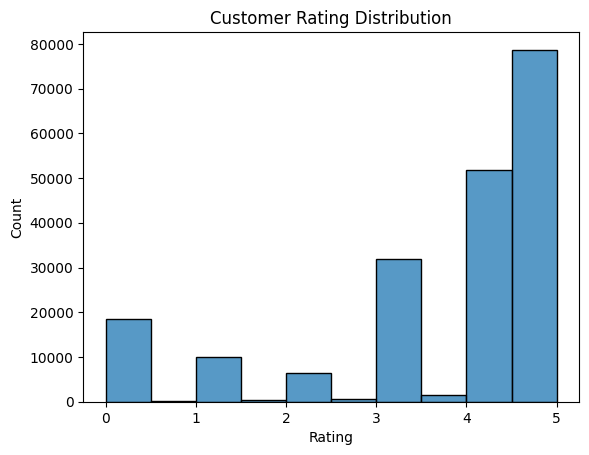

In [7]:
sns.histplot(
    comments["rate"],
    bins=10
)


plt.title(
    "Customer Rating Distribution"
)


plt.xlabel(
    "Rating"
)


plt.show()

# Recommendation Behavior


Recommendation status represents
customer willingness to recommend products.


In [8]:
comments[
    "recommendation_status"
].value_counts()

recommendation_status
recommended        136843
no_idea             19420
not_recommended     15123
Name: count, dtype: int64

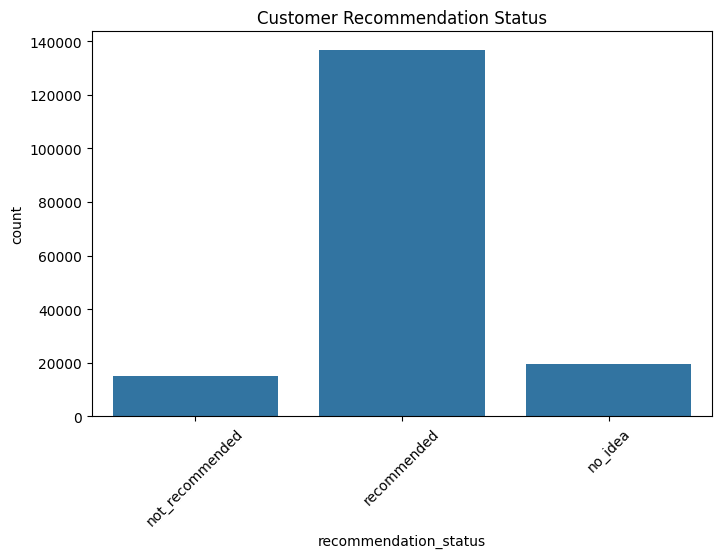

In [9]:
plt.figure(figsize=(8,5))


sns.countplot(
    data=comments,
    x="recommendation_status"
)


plt.title(
    "Customer Recommendation Status"
)


plt.xticks(rotation=45)

plt.show()

# Customer Satisfaction Index


We combine:


- Product rating
- Recommendation behavior


to create a simple satisfaction indicator.


In [10]:
comments["recommendation_score"] = (

    comments["recommendation_status"]

    .astype(str)

    .str.lower()

    .str.contains(
        "recommend"
    )

    .astype(int)

)

In [11]:
comments["customer_satisfaction_score"] = (

    0.5 *
    (comments["rate"]/5)

    +

    0.5 *
    comments["recommendation_score"]

)


comments[
    "customer_satisfaction_score"
].describe()

count    199997.000000
mean          0.743762
std           0.268029
min           0.000000
25%           0.500000
50%           0.900000
75%           1.000000
max           1.000000
Name: customer_satisfaction_score, dtype: float64

# Persian Text Preparation


We combine:


- Review title
- Review body


to create a complete customer message.


In [12]:
comments["full_text"] = (

    comments["title"]
    .fillna("")

    +

    " "

    +

    comments["body"]
    .fillna("")

)


comments[
    [
        "title",
        "body",
        "full_text"
    ]
].head()

,title,body,full_text
0,پیشنهاد نمیشود,به درد نمیخوره,پیشنهاد نمیشود به درد نمیخوره
1,بسته بندی بد,می‌تونست به عنوان یه کالای فرهنگی بهتر بسته بن...,بسته بندی بد می‌تونست به عنوان یه کالای فرهنگی...
2,برس ریمل,بسته بندیش خوب بود\r\n کاربرد و کیفیتشم خیلی خ...,برس ریمل بسته بندیش خوب بود\r\n کاربرد و کیفیت...
3,خوبه و خوشرنگ,به نظرم خوبه فقط یکم ظریفه. از رنگش خوشم اومد ...,خوبه و خوشرنگ به نظرم خوبه فقط یکم ظریفه. از ر...
4,برس رنگ مو,معمولیه اگه واسه خونه رنگ کردن شخصی میخواین او...,برس رنگ مو معمولیه اگه واسه خونه رنگ کردن شخصی...


In [13]:
def clean_text(text):

    if pd.isna(text):
        return ""


    text = str(text)


    text = text.replace(
        "ي",
        "ی"
    )


    text = text.replace(
        "ك",
        "ک"
    )


    text = re.sub(
        r"http\S+",
        "",
        text
    )


    text = re.sub(
        r"[^\w\sآ-ی]",
        "",
        text
    )


    text = re.sub(
        r"\s+",
        " ",
        text
    )


    return text.strip()

In [14]:
comments["clean_text"] = (

    comments["full_text"]

    .apply(clean_text)

)


comments[
    [
        "full_text",
        "clean_text"
    ]
].head()

,full_text,clean_text
0,پیشنهاد نمیشود به درد نمیخوره,پیشنهاد نمیشود به درد نمیخوره
1,بسته بندی بد می‌تونست به عنوان یه کالای فرهنگی...,بسته بندی بد میتونست به عنوان یه کالای فرهنگی ...
2,برس ریمل بسته بندیش خوب بود\r\n کاربرد و کیفیت...,برس ریمل بسته بندیش خوب بود کاربرد و کیفیتشم خ...
3,خوبه و خوشرنگ به نظرم خوبه فقط یکم ظریفه. از ر...,خوبه و خوشرنگ به نظرم خوبه فقط یکم ظریفه از رن...
4,برس رنگ مو معمولیه اگه واسه خونه رنگ کردن شخصی...,برس رنگ مو معمولیه اگه واسه خونه رنگ کردن شخصی...


In [15]:
comments["text_length"] = (

    comments["clean_text"]

    .apply(len)

)


comments[
    "text_length"
].describe()

count    199997.000000
mean         53.975475
std          66.475832
min           0.000000
25%          19.000000
50%          35.000000
75%          65.000000
max        3308.000000
Name: text_length, dtype: float64

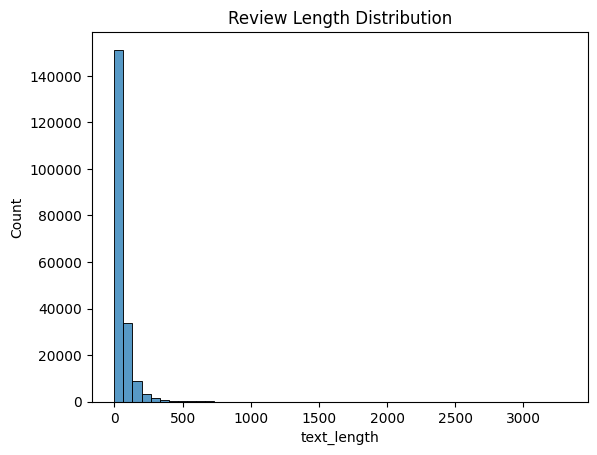

In [16]:
sns.histplot(
    comments["text_length"],
    bins=50
)


plt.title(
    "Review Length Distribution"
)


plt.show()

# Sentiment Creation


Since the dataset does not provide sentiment labels,
we create labels using customer ratings.


Mapping:


1-2 : Negative

3 : Neutral

4-5 : Positive


In [17]:
def create_sentiment(rate):

    if rate <=2:
        return "Negative"

    elif rate ==3:
        return "Neutral"

    else:
        return "Positive"

In [18]:
comments["sentiment"] = (

    comments["rate"]

    .apply(create_sentiment)

)


comments[
    "sentiment"
].value_counts()

sentiment
Positive    133828
Negative     35066
Neutral      31103
Name: count, dtype: int64

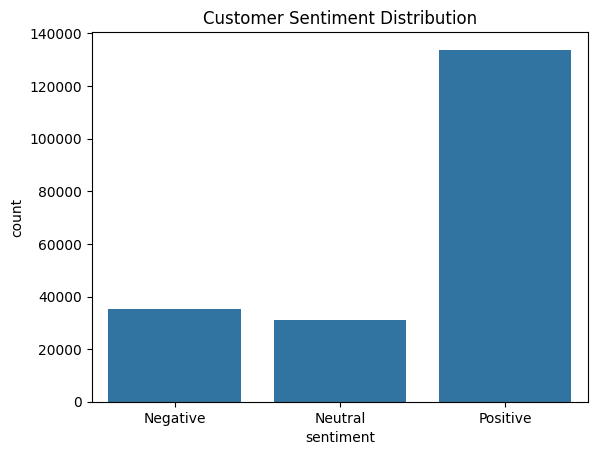

In [19]:
sns.countplot(
    data=comments,
    x="sentiment"
)


plt.title(
    "Customer Sentiment Distribution"
)


plt.show()

# TF-IDF Feature Extraction


Machine learning models require numerical features.

TF-IDF converts customer text into vectors.


In [20]:
X_text = comments[
    "clean_text"
]


y = comments[
    "sentiment"
]

In [21]:
tfidf = TfidfVectorizer(
    max_features=5000
)


X = tfidf.fit_transform(
    X_text
)


X.shape

(199997, 5000)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

# Baseline Sentiment Classification Model


Logistic Regression is used as
a simple and interpretable baseline.


In [23]:
model = LogisticRegression(
    max_iter=1000
)


model.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=1000)

In [24]:
predictions = model.predict(
    X_test
)

In [25]:
accuracy_score(
    y_test,
    predictions
)

0.727725

In [26]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

    Negative       0.64      0.35      0.45      7007
     Neutral       0.53      0.21      0.30      6290
    Positive       0.75      0.95      0.84     26703

    accuracy                           0.73     40000
   macro avg       0.64      0.50      0.53     40000
weighted avg       0.70      0.73      0.69     40000



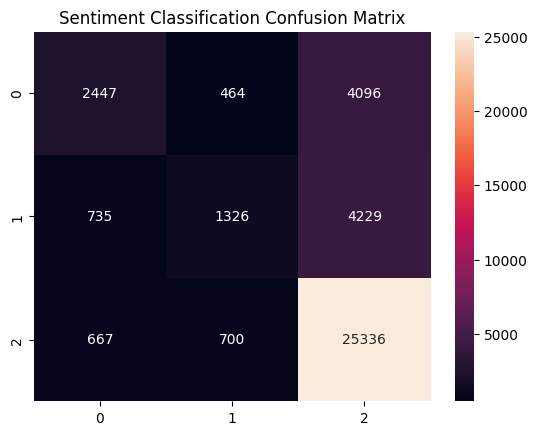

In [27]:
cm = confusion_matrix(
    y_test,
    predictions
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)


plt.title(
    "Sentiment Classification Confusion Matrix"
)


plt.show()

# Customer Pain Point Mining


Negative feedback helps identify:


- Product problems
- Missing information
- Content improvement opportunities


In [28]:
negative_reviews = comments[
    comments["sentiment"]
    ==
    "Negative"
]


negative_reviews[
    [
        "title",
        "body",
        "disadvantages"
    ]
].head(20)

,title,body,disadvantages
0,پیشنهاد نمیشود,به درد نمیخوره,NaN
1,بسته بندی بد,می‌تونست به عنوان یه کالای فرهنگی بهتر بسته بن...,['بسته بندی جالبی نداشت']
2,برس ریمل,بسته بندیش خوب بود\r\n کاربرد و کیفیتشم خیلی خ...,NaN
3,خوبه و خوشرنگ,به نظرم خوبه فقط یکم ظریفه. از رنگش خوشم اومد ...,NaN
6,بدک نیست,خوبه,NaN
10,NaN,اندازش کوچیکه بدرد رنگ مو نمیخوره,NaN
16,اصلا بدرد نمیخوره نخرید,بدرد نخور واقعی وقتی بدستم رسید برسش کج بود و ...,NaN
18,NaN,خوب,NaN
19,NaN,کیفیت چاپ خوب بود. اما چسب ها فاسد بودند,NaN
21,خوبه,ولی مال من دوتا از برسش شکسته دیجی کالا لطفا ب...,NaN


In [29]:
comments[
    "disadvantages"
].dropna().head(20)

1                              ['بسته بندی جالبی نداشت']
7                                             ['نداره ']
22                          ['شانه های برس زبر می باشد']
26                                             ['ندارد']
28                                             ['ندارد']
53                              ['فاصله زیاد دندانه ها']
57                                             ['نداره']
62                                         ['قیمت بالا']
64                                               ['هیچ']
73                                 ['رو درش حساب نکنید']
81                                            ['نداشت ']
99                                         ['قیمت بالا']
103                                            ['نداره']
117    ['پوشاندن شماره و لیبل دورغ\r', 'ارسال اشتباه ...
120                          ['بی دقتی در ارسال محصول ']
122                                      ['خیلی کوچیکه']
125    ['دوتا از چیزاش کیفیت بدی داره که توی عکس میزا...
127                       ['بهت

In [30]:
from collections import Counter


negative_text = " ".join(

    negative_reviews[
        "clean_text"
    ]

)


words = negative_text.split()


Counter(words).most_common(20)

[('و', 18788),
 ('بود', 9939),
 ('خیلی', 7866),
 ('به', 7773),
 ('از', 7765),
 ('که', 7060),
 ('خوب', 6992),
 ('من', 5467),
 ('کیفیت', 5259),
 ('این', 5128),
 ('کتاب', 5115),
 ('با', 4978),
 ('هم', 4422),
 ('رو', 4259),
 ('برای', 4129),
 ('عالی', 3897),
 ('اصلا', 3846),
 ('نیست', 3719),
 ('خوبه', 3629),
 ('ولی', 3596)]

# Business Insights


## Customer Experience


- Customer reviews provide direct feedback
about product satisfaction.


## Content Optimization


Negative reviews can reveal:


- Missing product information
- Incorrect expectations
- Content gaps


## AI Opportunities


Potential automation:


- Automatic review classification

- Customer complaint detection

- AI-generated content improvement suggestions

- Product page quality monitoring


# Summary & Next Steps


Completed:


✔ Customer satisfaction analysis

✔ Persian review preprocessing

✔ Sentiment classification

✔ NLP feature engineering

✔ Customer pain point extraction



Next Notebook:


# 06 - KPI Dashboard & Business Analytics


We will build:


- Content KPIs

- Product performance dashboard

- Category insights

- Executive reporting framework
